We compute return correlations across ETFs, individual stocks, and the combined asset universe, visualizing the cross-sectional relationships through correlation heatmaps. These assets form the investment universe for our portfolio construction. To prevent look-ahead bias, correlation analysis is performed using historical data from 2005–2019. Model evaluation is conducted over 2020–2025 using a rolling (walk-forward) training framework in which model parameters are dynamically re-estimated at each month.

In [65]:
import pandas as pd
from yahooquery import Ticker
import numpy as np
import matplotlib.pyplot as plt

In [66]:
etfs = ["SPY","QQQ","IWM","EFA","EEM","XLK","XLE","XLV","VNQ","TLT"]
stocks = ["AAPL","MSFT","NVDA","JPM","JNJ","XOM","KO","AMZN","CAT","V"]
all_tickers = stocks + etfs

In [67]:
etf_data = Ticker(etfs)
stock_data = Ticker(stocks)

etf_hist = etf_data.history(start="2005-01-01", end="2019-12-31", interval="1d")
stock_hist = stock_data.history(start="2005-01-01", end="2019-12-31", interval="1d")


In [68]:
etf_df = (
    etf_hist.reset_index()
        .loc[:, ["date", "symbol", "adjclose"]]
        .dropna(subset=["adjclose"])
)

stock_df = (
    stock_hist.reset_index()
        .loc[:, ["date", "symbol", "adjclose"]]
        .dropna(subset=["adjclose"])
)


In [69]:
etf_df = (etf_df
          .assign(date=pd.to_datetime(etf_df["date"]))
          .pivot(index="date", columns="symbol", values="adjclose")
          .sort_index())
          
stock_df = (stock_df
          .assign(date=pd.to_datetime(stock_df["date"]))
          .pivot(index="date", columns="symbol", values="adjclose")
          .sort_index())

all_tickers_df = pd.concat([etf_df, stock_df], axis=1)


In [70]:
etf_df.head()

symbol,EEM,EFA,IWM,QQQ,SPY,TLT,VNQ,XLE,XLK,XLV
date,,,,,,,,,,
2005-01-03,14.562676,28.951870,48.189293,33.695377,81.605972,44.738430,22.788919,9.636082,8.029546,20.910589
2005-01-04,14.114313,28.396843,47.156307,33.081184,80.608818,44.269588,22.446409,9.586499,7.879930,20.742405
2005-01-05,13.941525,28.378653,46.213776,32.876469,80.052544,44.506573,21.700237,9.545173,7.853075,20.707363
2005-01-06,13.932053,28.378653,46.458843,32.714375,80.459579,44.536781,21.867411,9.710456,7.830058,20.861534
2005-01-07,13.959029,28.251268,45.942337,32.884979,80.344246,44.637623,21.818480,9.633325,7.845399,20.847523


In [71]:
# find returns
etf_ret = etf_df.pct_change().dropna(how="all")
stock_ret = stock_df.pct_change().dropna(how="all")
all_tickers_ret = all_tickers_df.pct_change().dropna(how="all")

In [72]:
# --- correlation heatmap ---
etf_corr = etf_ret.corr()
stock_corr = stock_ret.corr()
all_tickers_corr = all_tickers_ret.corr()

def plot_corr_heatmap_annot(corr_mat, title, fmt="{:.2f}", fontsize=9):
    fig, ax = plt.subplots(figsize=(9, 7))
    im = ax.imshow(corr_mat.values, aspect="equal", vmin=-1, vmax=1)

    ax.set_title(title, pad=12)

    # ticks & labels
    ax.set_xticks(range(len(corr_mat.columns)))
    ax.set_yticks(range(len(corr_mat.index)))
    ax.set_xticklabels(corr_mat.columns, rotation=45, ha="right")
    ax.set_yticklabels(corr_mat.index)

    # gridlines
    ax.set_xticks(np.arange(-.5, len(corr_mat.columns), 1), minor=True)
    ax.set_yticks(np.arange(-.5, len(corr_mat.index), 1), minor=True)
    ax.grid(which="minor", linestyle="-", linewidth=0.5)
    ax.tick_params(which="minor", bottom=False, left=False)

    # colorbar
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Correlation", rotation=90)

    # --- annotate each cell with value ---
    vals = corr_mat.values
    for i in range(vals.shape[0]):
        for j in range(vals.shape[1]):
            ax.text(j, i, fmt.format(vals[i, j]), ha="center", va="center", fontsize=fontsize)

    plt.tight_layout()
    plt.show()


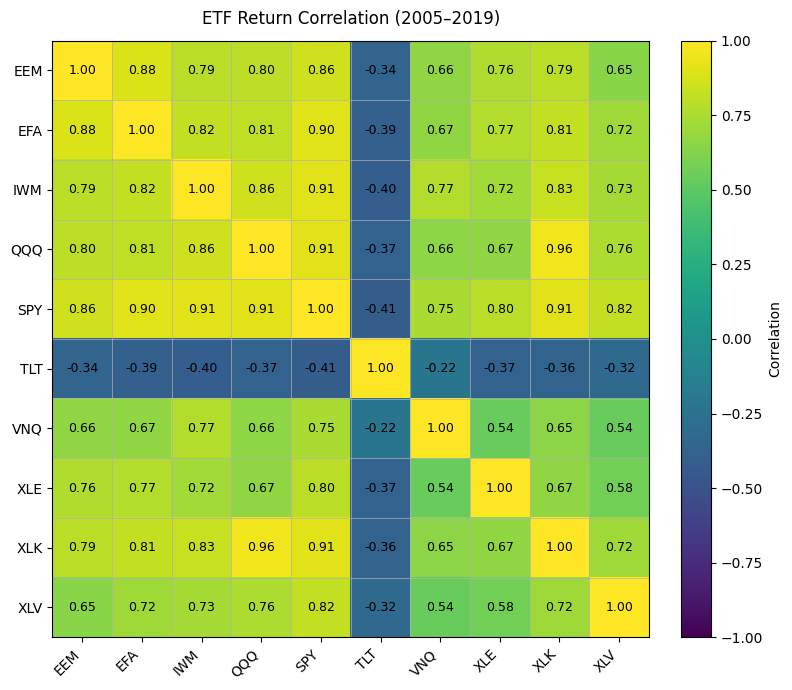

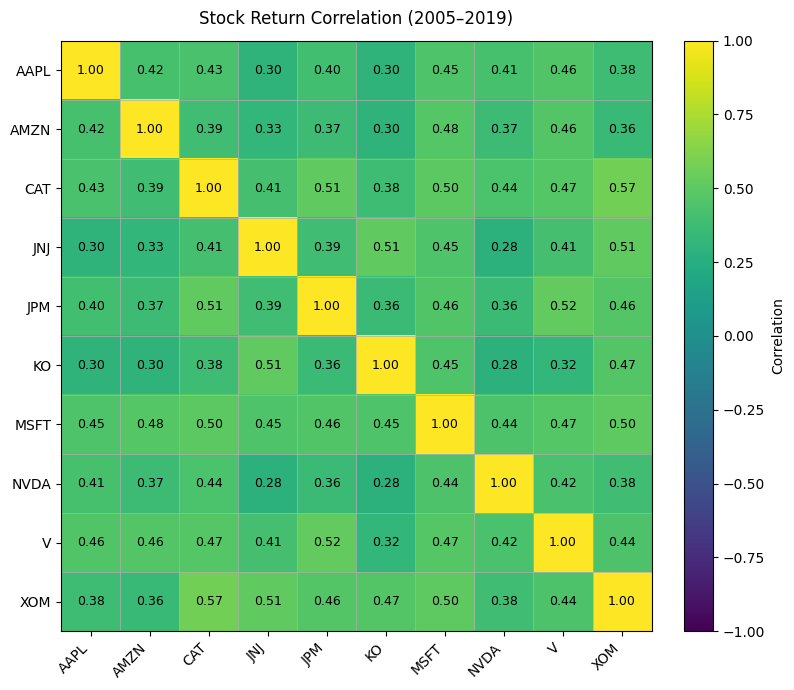

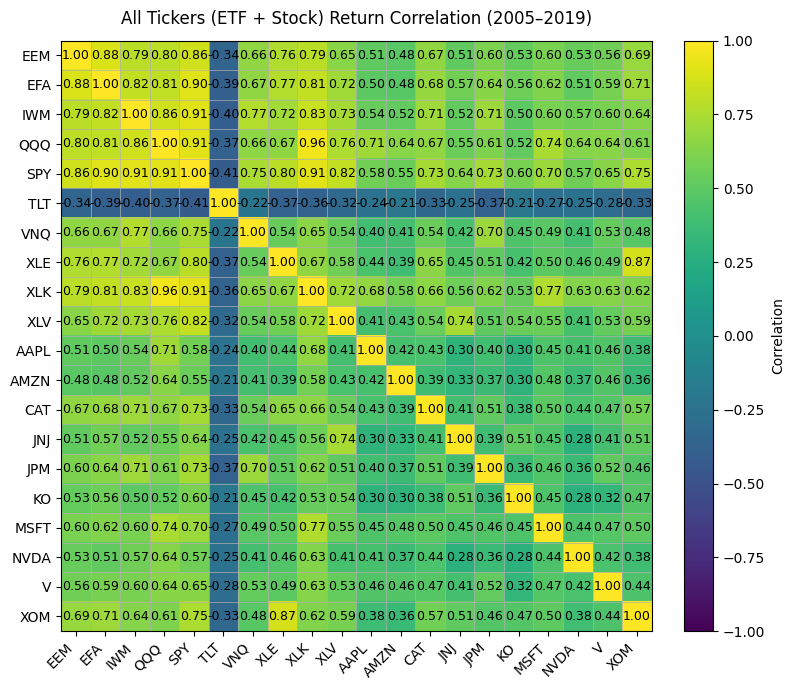

In [73]:
plot_corr_heatmap_annot(etf_corr, "ETF Return Correlation (2005–2019)", fmt="{:.2f}", fontsize=9)
plot_corr_heatmap_annot(stock_corr, "Stock Return Correlation (2005–2019)", fmt="{:.2f}", fontsize=9)
plot_corr_heatmap_annot(all_tickers_corr, "All Tickers (ETF + Stock) Return Correlation (2005–2019)", fmt="{:.2f}", fontsize=9)

The correlation heatmap reveals a highly clustered equity structure, with most assets exhibiting strong positive correlations, indicating significant redundancy in the investment universe. Only a limited number of assets, such as long-duration bonds (TLT), provide meaningful diversification. This structure leads to an ill-conditioned covariance matrix, which explains the instability of traditional MVO. The improved performance of the proposed methods—particularly Dynamic Black-Litterman and covariance shrinkage—stems from their ability to mitigate estimation error and control overreaction in a highly correlated asset universe.